# Project 2: Animal classification - Alisa Podolska, Yulian Kisil

In [1]:
import torch
torch.cuda.is_available()

True

In [2]:
import os
import time
import json
import random
import shutil
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image, UnidentifiedImageError
from tqdm import tqdm
from itertools import cycle
from collections import Counter
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader
import torchvision.transforms.functional as TF
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (classification_report, confusion_matrix, precision_recall_fscore_support, f1_score, roc_curve, auc)
import wandb
warnings.filterwarnings("ignore")

## EDA
The exploratory data analysis includes the following steps:

- Translation of class names from Italian to English  
- Visualization of sample images from each class  
- Analysis of class distribution to detect imbalance  

Additionally, the following data quality checks are performed:

- Image file format verification  
- Image size consistency check  
- Number of color channels (RGB)  
- Aspect ratio validation  
- Detection and removal of corrupted or unreadable images  

In [3]:
data_dir = "./dataset/raw-img"

### Translation

In [ ]:
mapping = {
    "cane": "dog",
    "cavallo": "horse",
    "elefante": "elephant",
    "farfalla": "butterfly",
    "gallina": "chicken",
    "gatto": "cat",
    "mucca": "cow",
    "pecora": "sheep",
    "ragno": "spider",
    "scoiattolo": "squirrel"
}
for old_name, new_name in mapping.items():
    old_path = os.path.join(data_dir, old_name)
    new_path = os.path.join(data_dir, new_name)

    if os.path.exists(old_path):
        os.rename(old_path, new_path)
    else:
        print(f"Folder'{old_name}' not found.")


In [5]:
classes = os.listdir(data_dir)
print("Classes:", classes)

for cls in classes:
    cnt = len(os.listdir(os.path.join(data_dir, cls)))
    print(f"{cls}: {cnt} images")

Classes: ['horse', 'cow', 'elephant', 'chicken', 'dog', 'cat', 'spider', 'butterfly', 'sheep', 'squirrel']
horse: 2623 images
cow: 1866 images
elephant: 1446 images
chicken: 3098 images
dog: 4863 images
cat: 1668 images
spider: 4821 images
butterfly: 2112 images
sheep: 1820 images
squirrel: 1862 images


### Visual sanity-chack

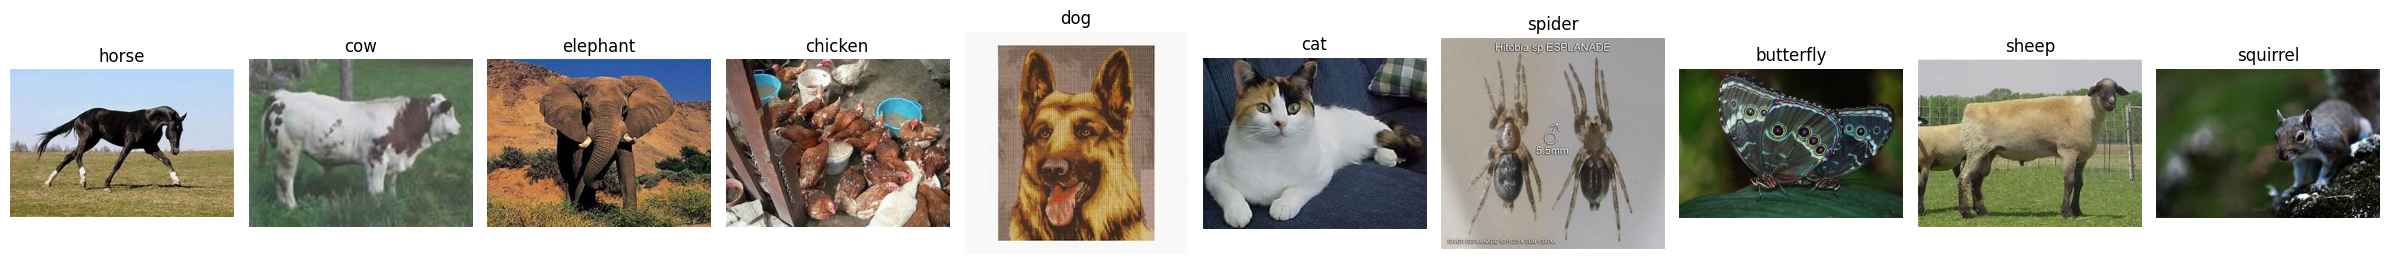

In [6]:
plt.figure(figsize=(24, 8))

for i, cls in enumerate(classes):
    cls_dir = os.path.join(data_dir, cls)
    img_name = random.choice(os.listdir(cls_dir))
    img_path = os.path.join(cls_dir, img_name)
    
    img = Image.open(img_path)

    plt.subplot(1, len(classes), i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Distribution

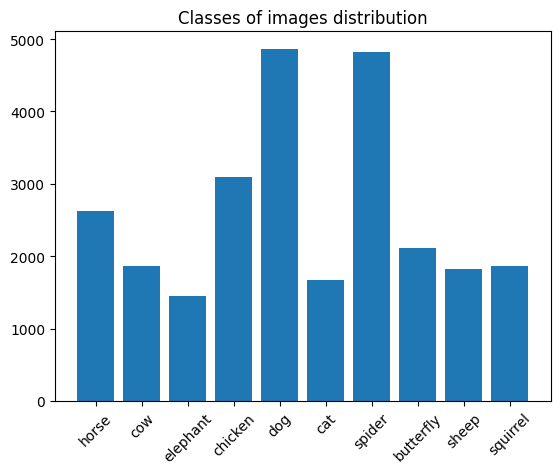

In [7]:
counts = {cls: len(os.listdir(os.path.join(data_dir, cls))) for cls in classes}
plt.bar(counts.keys(), counts.values())
plt.xticks(rotation=45)
plt.title("Classes of images distribution")
plt.show()

### Checking format, size and aspect-reisho

In [8]:
shapes=[]
channels=[]

for cls in classes:
    for img_name in os.listdir(os.path.join(data_dir,cls))[:200]:
        img=Image.open(os.path.join(data_dir,cls,img_name))
        shapes.append(img.size);channels.append(img.mode)
        
shapes=np.array(shapes)
print("Avarage size:",shapes.mean(axis=0))
print("Min:",shapes.min(axis=0))
print("Max:",shapes.max(axis=0))
print("Channels:",set(channels))

Avarage size: [333.762  257.3825]
Min: [60 57]
Max: [6720 4608]
Channels: {'RGB', 'RGBA'}


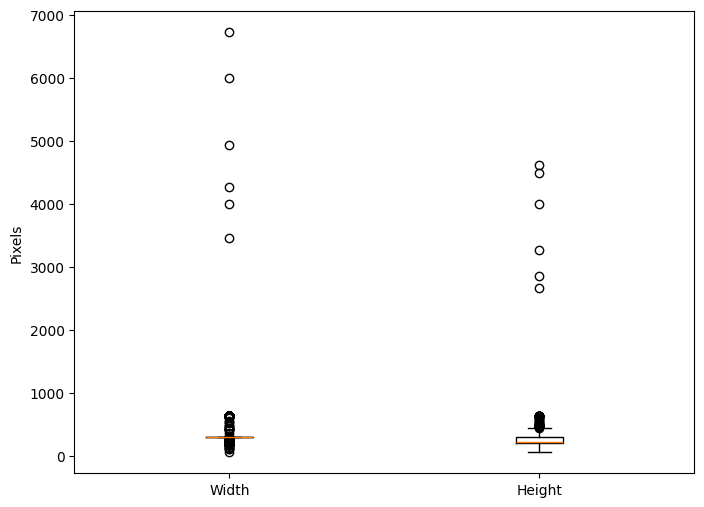

In [9]:
shapes = []
channels = []

for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    for img_name in os.listdir(cls_path)[:200]:
        img_path = os.path.join(cls_path, img_name)
        img = Image.open(img_path)
        shapes.append(img.size)
        channels.append(img.mode)

shapes = np.array(shapes)
widths = shapes[:, 0]
heights = shapes[:, 1]

plt.figure(figsize=(8, 6))
plt.boxplot([widths, heights], labels=["Width", "Height"], showfliers=True)
plt.ylabel("Pixels")
plt.show()

### Checking for broken images

In [66]:
bad = []
for cls in classes:
    for file in os.listdir(os.path.join(data_dir, cls)):
        path = os.path.join(data_dir, cls, file)
        try:
            Image.open(path).verify()
        except:
            bad.append(path)

bad

[]

During the analysis, it was found that there are not problems with our data, but image height and width contain outliers, which leads to significant variation in image sizes across the dataset.

Therefore, an important step in the preprocessing stage is image resizing.  

## Data preprocessing
During the preprocessing stage, the following steps were performed:

- The dataset was split into training, validation, and test sets with a ratio of **70/20/10**  
- All images were resized to a fixed resolution  
- Image normalization was applied using **ImageNet mean and standard deviation**  
- Two different versions of data augmentation were implemented  
- The processed datasets were wrapped into **PyTorch DataLoaders**   

Additionally, the following visualizations were created:

- Images after transform augmentation
- Distribution of image width and height after resizing  
- Visualization of input images after preprocessing

### Data split 
Train - 70  
Validation - 20  
Test - 10

In [10]:
train_dir = "dataset/train"
val_dir = "dataset/val"
test_dir = "dataset/test"

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

for cls in classes:
    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(val_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(test_dir, cls), exist_ok=True)

    images = os.listdir(os.path.join(data_dir, cls))
    train, test = train_test_split(images, test_size=0.1, random_state=42)
    train, val = train_test_split(train, test_size=0.2, random_state=42)

    for name in train:
        shutil.copy(os.path.join(data_dir, cls, name), os.path.join(train_dir, cls, name))

    for name in val:
        shutil.copy(os.path.join(data_dir, cls, name), os.path.join(val_dir, cls, name))

    for name in test:
        shutil.copy(os.path.join(data_dir, cls, name), os.path.join(test_dir, cls, name))

### Resize + mormalization

In [11]:
img_size = 224

train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

### Data Augmentation (only for train)

In [12]:
train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomResizedCrop(img_size, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

The image is first resized, then randomly flipped horizontally to simulate mirrored views. A small random rotation is applied to introduce orientation variation. ColorJitter is used to slightly change brightness, contrast, and saturation, making the model less sensitive to lighting conditions. RandomResizedCrop selects and zooms into a random part of the image to help the model learn from different object scales and positions. Finally, the image is converted to a tensor and normalized using the standard ImageNet mean and standard deviation.

In [71]:
from torchvision.transforms.v2 import (
    Compose, Resize, RandomHorizontalFlip, RandomRotation, ColorJitter,
    RandomResizedCrop, ToImage, ToDtype, Normalize
)

train_transform = Compose([
    Resize((img_size, img_size)),
    RandomHorizontalFlip(),
    RandomRotation(15),
    ColorJitter(0.2, 0.2, 0.2),
    RandomResizedCrop(img_size, scale=(0.8, 1.0)),
    ToImage(),
    ToDtype(torch.float32, scale=True),
    Normalize(mean=[0.485, 0.456, 0.406],
              std=[0.229, 0.224, 0.225])
])

Augmentations based on `torchvision.transforms.v2` demonstrated higher execution speed during training, which made it possible to accelerate the model training process without any loss in the quality of the transformations.

### Vizualisation

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8781574..2.64].


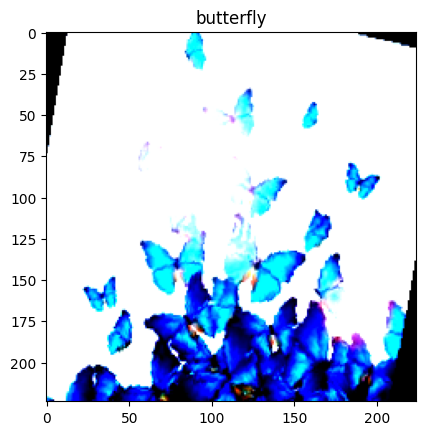

In [13]:
dataset = datasets.ImageFolder(train_dir, transform=train_transform)
img, label = dataset[0]

plt.imshow(img.permute(1,2,0))
plt.title(dataset.classes[label])
plt.show()


### DataLoader

In [14]:
train_ds = datasets.ImageFolder(train_dir, transform=train_transform)
val_ds = datasets.ImageFolder(val_dir, transform=val_transform)
test_ds = datasets.ImageFolder(test_dir, transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)
test_loader = DataLoader(test_ds, batch_size=32)

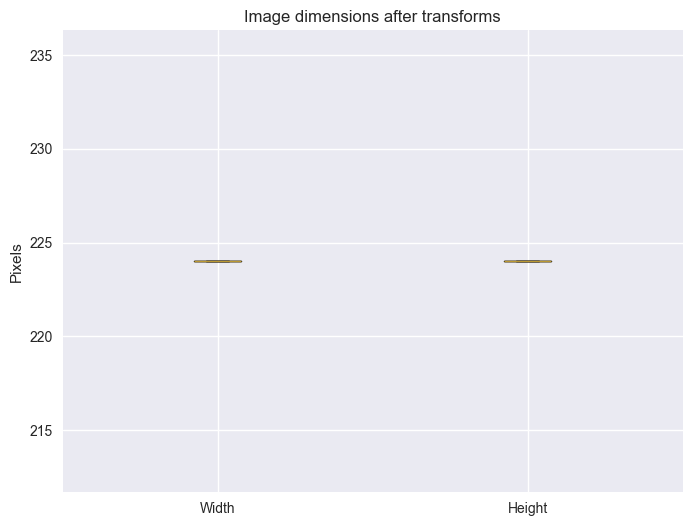

In [74]:
resized_widths = []
resized_heights = []

for img, _ in train_ds:      
    _, h, w = img.shape      
    resized_widths.append(w)
    resized_heights.append(h)
plt.figure(figsize=(8, 6))
plt.boxplot([resized_widths, resized_heights], labels=["Width", "Height"], showfliers=True)
plt.title("Image dimensions after transforms")
plt.ylabel("Pixels")
plt.show()

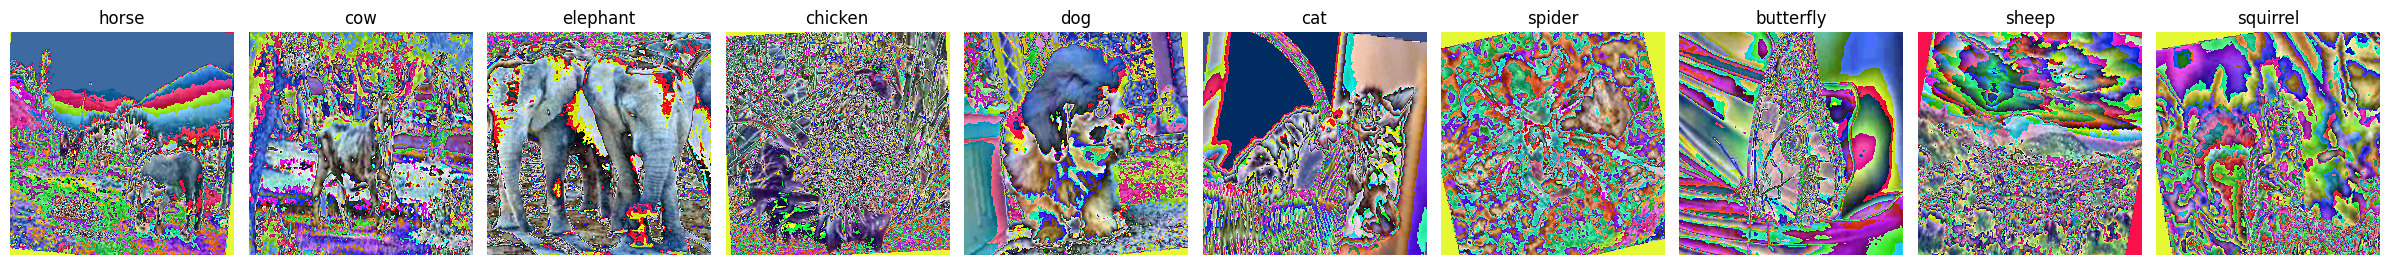

In [15]:
plt.figure(figsize=(24, 8))

for i, cls in enumerate(classes):
    class_idx = train_ds.class_to_idx[cls]
    indices = [j for j, (_, label) in enumerate(train_ds.samples) if label == class_idx]
    idx = random.choice(indices)

    img, _ = train_ds[idx]
    img = F.to_pil_image(img)

    plt.subplot(1, len(classes), i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Model Architectures and Experiments

In this section, different neural network architectures were explored to identify the most suitable solution for this task. The selected architectures were also compared to existed models introduced during the lecture.

LeNet was used only as a baseline to understand the expected performance level. More complex and modern architectures were implemented in two versions:
- With pre-trained weights  
- Without pre-training  

The evaluation in this section focuses on the custom architectures developed for this project.  
All experiments and training results for every architecture are logged and tracked using **Wandb** tool.


### Our first small CNN

#### Imports and Config Loading

In [16]:
# Function to load config from JSON
def load_config(config_path='config.json'):
    with open(config_path, 'r') as f:
        config = json.load(f)
    print(f"Loaded config: {config['model']['name']} from {config_path}")
    return config


config = load_config('config.json')  # v1: basic

img_size = config['model']['input_size']
batch_size = config['training']['batch_size']
num_classes = config['model']['num_classes']
device = config['training']['device']
epochs = config['training']['epochs']

Loaded config: CustomCNN_v1 from config.json


In [25]:
class ConfigurableAnimalModel(nn.Module):
    def __init__(self, config):
        super(ConfigurableAnimalModel, self).__init__()
        self.config = config
        model_cfg = config['model']
        train_cfg = config['training']

        self.features = nn.Sequential()
        prev_out_ch = model_cfg['blocks'][0]['in_channels']
        use_bn = train_cfg.get('use_bn', False) 

        for i, block_cfg in enumerate(model_cfg['blocks']):
            block = nn.Sequential(
                nn.Conv2d(block_cfg['in_channels'], block_cfg['out_channels'],
                          kernel_size=block_cfg['kernel_size'], padding=block_cfg['padding'])
            )
            if use_bn: 
                block.add_module('bn', nn.BatchNorm2d(block_cfg['out_channels']))
            block.add_module('relu', nn.ReLU())
            block.add_module('pool', nn.MaxPool2d(2))
            self.features.add_module(f'conv_block_{i}', block)
            prev_out_ch = block_cfg['out_channels']

        num_pools = len(model_cfg['blocks'])
        feat_h = model_cfg['input_size'] // (2 ** num_pools)
        feat_w = model_cfg['input_size'] // (2 ** num_pools)
        linear_input = prev_out_ch * feat_h * feat_w

        classifier_cfg = model_cfg['classifier']
        self.classifier = nn.Sequential()
        self.classifier.add_module('flatten', nn.Flatten())
        current_size = linear_input
        fc_layers = classifier_cfg.get('fc_layers',
                                       [{'in': None, 'out': classifier_cfg['hidden_size']}])  # Default: 1 layer
        for j, layer_cfg in enumerate(fc_layers):
            in_size = linear_input if layer_cfg['in'] is None else layer_cfg['in'] 
            self.classifier.add_module(f'fc_{j}', nn.Linear(in_size, layer_cfg['out']))
            self.classifier.add_module(f'relu_{j}', nn.ReLU())
            current_size = layer_cfg['out']

        self.classifier.add_module('dropout', nn.Dropout(classifier_cfg['dropout_rate']))

        self.classifier.add_module('out', nn.Linear(current_size, model_cfg['num_classes']))

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

    @classmethod
    def from_config(cls, config_path):  # Static method for easy creation
        config = load_config(config_path)
        return cls(config)


In [26]:
model = ConfigurableAnimalModel.from_config('config.json').to(device)

Loaded config: CustomCNN_v1 from config.json


### Loss and Optimizer Setup

In [36]:
train_cfg = config['training']

if train_cfg['criterion'] == 'CrossEntropyLoss':
    criterion = nn.CrossEntropyLoss()
else:
    raise ValueError(f"Unsupported criterion: {train_cfg['criterion']}")

optimizer_class = getattr(optim, train_cfg['optimizer'])
optimizer_kwargs = {'lr': train_cfg['lr']}
if train_cfg['optimizer'] == 'SGD':
    optimizer_kwargs['momentum'] = train_cfg.get('momentum', 0.9)  # For v3
optimizer = optimizer_class(model.parameters(), **optimizer_kwargs)

### Training

In [37]:
def train_epoch(model, loader, criterion, optimizer):
    model_t = 0
    loader_t = 0
    model.train()
    total_loss, total_correct = 0, 0
    prev_time = time.perf_counter()
    for images, labels in loader:
        loader_time = time.perf_counter() - prev_time
        loader_t += loader_time
        images, labels = images.to(device), labels.to(device)
        model_start = time.perf_counter()
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total_correct += (outputs.argmax(1) == labels).sum().item()
        prev_time = time.perf_counter()
        model_t += prev_time - model_start
    print(f"Model time: {model_t:.2f}s, Loader time: {loader_t:.2f}s")

    return total_loss / len(loader.dataset), total_correct / len(loader.dataset)

### Validation

In [38]:
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, total_correct = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            total_correct += (outputs.argmax(1) == labels).sum().item()

    return total_loss / len(loader.dataset), total_correct / len(loader.dataset)

### First experiment + Wandb

In [ ]:
exp_cfg = config['experiment']
wandb.login()

wandb.init(
    project=exp_cfg['wandb_project'],
    name=exp_cfg['wandb_name'],
    config=config  
)
for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = eval_epoch(model, val_loader, criterion)

    print(f"[v1 {epoch + 1}/{epochs}] Train Acc={train_acc:.4f}  Val Acc={val_acc:.4f}")
    wandb.log({
        "epoch": epoch + 1,
        "train/loss": train_loss,
        "train/accuracy": train_acc,
        "val/loss": val_loss,
        "val/accuracy": val_acc,
    })
wandb.finish()


test_loss_v1, test_acc_v1 = eval_epoch(model, test_loader, criterion)
print(f"[v1 Final] Test Acc={test_acc_v1:.4f}")

### Custom Configurable Model — Experiment v2 

In this experiment, we train the second version of our **ConfigurableAnimalModel**, where the entire architecture and training setup are controlled through an external JSON configuration. The model is built dynamically using the `from_config()` method, which constructs convolutional layers, fully connected layers, dropout, and batch normalization exactly as described in `config_v2.json`. The training loop uses standard CrossEntropyLoss together with an optimizer defined in the config (e.g., Adam), and all hyperparameters such as learning rate, batch size, and number of epochs are sourced directly from the configuration file. After training, we also evaluate the model on the test set to measure its final performance.


### Deeper CNN Architecture

#### Overview

The goal of Experiment v2 was to evaluate how increasing the depth of the dynamically constructed CNN affects feature extraction quality, convergence behavior, and model stability. Building upon the baseline architecture from v1, we introduced a deeper configuration while keeping the training methodology mostly unchanged. This allows isolating the effect of architectural depth as the primary experimental variable.


#### **Changes Compared to v1**

* **Added a 5th convolutional block** (256 -> 512 channels)
* **Increased training epochs:** 15 -> 20
* **Lowered learning rate:** 1e-4 -> 5e-5
* **Other settings unchanged:** Adam optimizer, no BatchNorm, CUDA training


#### **Rationale Behind the Changes**

1. **Deeper Feature Extraction**
   The additional convolutional block increases the representational capacity of the network, enabling it to learn more complex patterns and richer hierarchical features.

2. **Reduced Learning Rate**
   Deeper architectures tend to be more sensitive during optimization. A smaller learning rate provides smoother gradient updates and prevents oscillations or divergence during training.

3. **More Training Epochs**
   The expanded network requires more iterations to properly converge since it contains more layers and parameters.


#### **Observed Improvements**

* **Enhanced feature representation** due to increased depth
* **More stable validation accuracy**, indicating improved learning dynamics
* **Reduced overfitting**


This experiment demonstrates that **architectural depth alone, even without normalization or advanced optimizers, can significantly influence training behavior**. It establishes a stepping stone toward more advanced improvements introduced in Experiment v3.



In [ ]:
config_v2 = load_config('config_v2.json')
model_v2 = ConfigurableAnimalModel.from_config('config_v2.json').to(device)  # Static method

train_cfg_v2 = config_v2['training']
if train_cfg_v2['criterion'] == 'CrossEntropyLoss':
    criterion_v2 = nn.CrossEntropyLoss()
else:
    raise ValueError(f"Unsupported: {train_cfg_v2['criterion']}")

optimizer_class_v2 = getattr(optim, train_cfg_v2['optimizer'])
optimizer_v2 = optimizer_class_v2(model_v2.parameters(), lr=train_cfg_v2['lr'])

epochs_v2 = config_v2['training']['epochs']

exp_cfg_v2 = config_v2['experiment']
wandb.init(
    project=exp_cfg_v2['wandb_project'],
    name=exp_cfg_v2['wandb_name'],  # "CustomCNN_v2_Deeper"
    config=config_v2
)

for epoch in range(epochs_v2):
    train_loss, train_acc = train_epoch(model_v2, train_loader, criterion_v2, optimizer_v2)
    val_loss, val_acc = eval_epoch(model_v2, val_loader, criterion_v2)

    print(f"[v2 {epoch + 1}/{epochs_v2}] Train Acc={train_acc:.4f}  Val Acc={val_acc:.4f}")
    wandb.log({
        "epoch": epoch + 1,
        "train/loss": train_loss,
        "train/accuracy": train_acc,
        "val/loss": val_loss,
        "val/accuracy": val_acc,
    })

wandb.finish()

test_loss_v2, test_acc_v2 = eval_epoch(model_v2, test_loader, criterion_v2)
print(f"[v2 Final] Test Acc={test_acc_v2:.4f}")

In [23]:
torch.save(model_v2.state_dict(), "cnn_v2.pth")


### Custom Configurable Model — Experiment v3

This experiment trains the third version of the **ConfigurableAnimalModel**, which includes a more advanced training setup defined in `config_v3.json`. Along with configurable architecture and optimizer settings, this version introduces **SGD with momentum** and optionally a **learning rate scheduler (StepLR)** to improve training stability and convergence. As in previous versions, all components of the model-including convolution blocks, batch normalization, dropout, and fully connected layers-are built dynamically through the configuration system. After finishing all epochs, we compute the final test accuracy to evaluate how the scheduler and updated training strategy influence performance.

### BatchNorm, SGD, Learning Rate Scheduler, and Enhanced Classifier

#### Overview

Experiment v3 introduces several essential improvements to stabilize and accelerate training of deeper CNNs. After observing the limitations of the v2 architecture—particularly its sensitivity to optimization and slower convergence—we incorporated normalization layers, a more robust optimization strategy, and a learning rate scheduler. This experiment represents a transition from simple baseline exploration to a more production-grade training setup.


#### **Changes Compared to v2**

* **Added Batch Normalization** to all convolutional blocks
* **Optimizer changed:** Adam -> **SGD with Momentum (0.9)**
* **Learning rate increased:** 0.00005 -> **0.01**
* **Added StepLR scheduler** (step_size=10, gamma=0.1)
* **Enhanced classifier:** 1024 -> 512 -> output
* **Dropout reduced:** 0.5 -> 0.3


#### **Rationale Behind the Changes**

1. **Batch Normalization for Stability**
   BN reduces internal covariate shift, enabling higher learning rates and dramatically improving gradient flow in deep networks.

2. **SGD with Momentum vs. Adam**
   SGD with momentum is known to generalize better in large convolutional architectures (VGG, ResNet).
   It provides smoother, more consistent optimization compared to Adam, especially when paired with BN.

3. **Higher Learning Rate**
   BatchNorm allows using significantly larger learning rates without destabilizing training.
   This speeds up convergence during the early stages.

4. **Learning Rate Scheduler (StepLR)**
   Reduces the learning rate over time, guiding the model from fast initial learning into refined fine-tuning.

5. **Deeper Fully Connected Head**
   The added 1024 -> 512 layers improve high-level feature abstraction before classification.

6. **Reduced Dropout**
   With BN in place, less aggressive regularization is required.


#### **Observed Improvements**

* **Higher training and validation accuracy**
* **Better generalization**, driven by BN + scheduler + momentum
* **More meaningful decision boundaries**, enabled by the deeper classifier
* **Reduced variance between epochs**, indicating controlled optimization dynamics


#### **Cause-Effect Relationship**

BatchNorm -> stabilizes activations ->
allows **higher learning rate** ->
which works effectively with **SGD + Momentum** ->
and **StepLR scheduler** refines optimization over time ->
leading to **faster convergence and better final accuracy**.

The combination of these techniques transforms the model from a research-prototype architecture into a more **robust, scalable, and production-ready CNN pipeline**.


In [ ]:
config_v3 = load_config('config_v3.json')
device = torch.device("cuda")
model_v3 = ConfigurableAnimalModel.from_config('config_v3.json').to(device)

train_cfg_v3 = config_v3['training']
if train_cfg_v3['criterion'] == 'CrossEntropyLoss':
    criterion_v3 = nn.CrossEntropyLoss()
else:
    raise ValueError(f"Unsupported: {train_cfg_v3['criterion']}")

optimizer_class_v3 = getattr(optim, train_cfg_v3['optimizer'])
optimizer_v3 = optimizer_class_v3(model_v3.parameters(), lr=train_cfg_v3['lr'], momentum=0.9)

scheduler_cfg = train_cfg_v3.get('scheduler', {})
scheduler_v3 = None
if scheduler_cfg.get('type') == 'StepLR':
    scheduler_v3 = StepLR(optimizer_v3, step_size=scheduler_cfg['step_size'], gamma=scheduler_cfg['gamma'])

epochs_v3 = config_v3['training']['epochs']

exp_cfg_v3 = config_v3['experiment']
wandb.init(
    project=exp_cfg_v3['wandb_project'],
    name=exp_cfg_v3['wandb_name'],  # "CustomCNN_v3_BN_SGD_Scheduler"
    config=config_v3
)

for epoch in range(epochs_v3):
    train_loss, train_acc = train_epoch(model_v3, train_loader, criterion_v3, optimizer_v3)
    val_loss, val_acc = eval_epoch(model_v3, val_loader, criterion_v3)

    print(
        f"[v3 {epoch + 1}/{epochs_v3}] Train Acc={train_acc:.4f}  Val Acc={val_acc:.4f}  LR={optimizer_v3.param_groups[0]['lr']:.6f}")
    wandb.log({
        "epoch": epoch + 1,
        "train/loss": train_loss,
        "train/accuracy": train_acc,
        "val/loss": val_loss,
        "val/accuracy": val_acc,
        "lr": optimizer_v3.param_groups[0]['lr']
    })

    if scheduler_v3:
        scheduler_v3.step()

wandb.finish()
torch.save(model_v3.state_dict(), "cnn_v3.pth")

test_loss_v3, test_acc_v3 = eval_epoch(model_v3, test_loader, criterion_v3)
print(f"[v3 Final] Test Acc={test_acc_v3:.4f}")

### LeNet

In this section, we train **LeNet**, one of the earliest convolutional neural networks, originally designed for handwritten digit recognition. Although simple by today’s standards, it is a useful baseline model to compare against deeper and more modern architectures. Our LeNet implementation uses two convolution–pooling blocks followed by a small fully connected classifier, adapted to handle 224×224 RGB images and output 10 animals classes.

The model is trained for 15 epochs using the Adam optimizer and CrossEntropyLoss. During each epoch, we monitor both training and validation accuracy to evaluate how well this classic architecture performs on a more complex, real-world dataset.


In [20]:
import os
os.environ["WANDB_DISABLE_CORE"] = "true"
os.environ["WANDB_REQUIRE_SERVICE"] = "true"


In [ ]:
import wandb
wandb.init(project="animals", entity="xpodolskaa-stuba")


In [22]:
class LeNet(nn.Module):
    def __init__(self, num_classes):
        super(LeNet, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 6, kernel_size=5),  
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(6, 16, kernel_size=5), 
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # 224 х 224
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 53 * 53, 120),
            nn.ReLU(),
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Linear(84, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [23]:
model = LeNet(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [ ]:
import wandb
wandb.login()

wandb.init(
    project="animals",
    name="LeNet",
    config={
        "epochs": 15,
        "lr": 1e-4,
        "batch_size": train_loader.batch_size,
        "optimizer": "Adam",
        "model": "LeNet"
    }
)


In [ ]:
wandb.login()

wandb.init(
    project="animals",
    name="LeNet",
    config={
        "epochs": 15,
        "lr": 1e-4,
        "batch_size": train_loader.batch_size,
        "optimizer": "Adam",
        "model": "LeNet"
    }
)
epochs = 15

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = eval_epoch(model, val_loader, criterion)

    print(f"[{epoch+1}/{epochs}] Train Acc={train_acc:.4f}  Val Acc={val_acc:.4f}")

    
    wandb.log({
        "epoch": epoch + 1,
        "train/loss": train_loss,
        "train/accuracy": train_acc,
        "val/loss": val_loss,
        "val/accuracy": val_acc,
    })

In [31]:
epochs = 15

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = eval_epoch(model, val_loader, criterion)

    print(f"[{epoch+1}/{epochs}] Train Acc={train_acc:.4f}  Val Acc={val_acc:.4f}")

    
    wandb.log({
        "epoch": epoch + 1,
        "train/loss": train_loss,
        "train/accuracy": train_acc,
        "val/loss": val_loss,
        "val/accuracy": val_acc,
    })


7.421533321263269
71.8319747033529
[1/15] Train Acc=0.4361  Val Acc=0.4662
7.4198644566349685
68.82559059909545
[2/15] Train Acc=0.4587  Val Acc=0.4847
7.421509635169059
67.73284270893782
[3/15] Train Acc=0.4759  Val Acc=0.4890
7.421467535197735
68.79699815995991
[4/15] Train Acc=0.4966  Val Acc=0.4851
7.432263103546575
70.76057340670377
[5/15] Train Acc=0.5037  Val Acc=0.5247
7.429230439243838
70.53141029225662
[6/15] Train Acc=0.5177  Val Acc=0.5348
7.420936400303617
69.46358028310351
[7/15] Train Acc=0.5326  Val Acc=0.5512
7.421177799347788
69.55139511218295
[8/15] Train Acc=0.5400  Val Acc=0.5616
7.426971870707348
70.45019987924024
[9/15] Train Acc=0.5499  Val Acc=0.5583
7.426169752841815
69.73099021450616
[10/15] Train Acc=0.5598  Val Acc=0.5522
7.416563962586224
67.32665295526385
[11/15] Train Acc=0.5774  Val Acc=0.5817
7.426847729599103
72.79298161272891
[12/15] Train Acc=0.5825  Val Acc=0.5788
7.42227708385326
70.94592385715805
[13/15] Train Acc=0.5864  Val Acc=0.5772
7.4139908

### More modern and deeper architectures

In the next section, several existed convolutional neural network architectures were evaluated on the Animals10 dataset. All models were trained for 15 epochs using the Adam optimizer and CrossEntropy loss. Training and validation metrics were logged using **Wandb**.

For **ResNet-50** and **Inception-v1 (GoogLeNet)**, two versions were implemented:
- With pretrained ImageNet weights  
- Without pretraining (trained from scratch)  

This allowed a direct comparison of how transfer learning affects model performance.

The following additional architectures were also evaluated using their pretrained ImageNet versions:
- **MobileNet-v2**
- **DenseNet-121**
- **VGG-16**
- **AlexNet**

For each of these models, the final classification layer was replaced to match the 10 classes of our dataset. During training, both training and validation accuracy were monitored.

The final accuracy results and performance comparisons for all models are presented in the corresponding subsections dedicated to each architecture.

### AlexNet

Train accuracy = 0.96

Val accuracy = 0.97

In [23]:
from torchvision.models import alexnet

In [24]:
def build_alexnet(num_classes):
    model = alexnet(weights="IMAGENET1K_V1")  
    model.classifier[6] = nn.Linear(4096, num_classes)  
    return model.to(device)


In [25]:
model = build_alexnet(num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [ ]:
wandb.init(
    project="animals",
    name="AlexNet",
    config={
        "epochs": 15,
        "lr": 1e-4,
        "batch_size": train_loader.batch_size,
        "optimizer": "Adam",
        "model": model
    }
)
for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = eval_epoch(model, val_loader, criterion)

    print(f"[{epoch+1}/{epochs}] Train Acc={train_acc:.4f}  Val Acc={val_acc:.4f}")
    wandb.log({
        "epoch": epoch + 1,
        "train/loss": train_loss,
        "train/accuracy": train_acc,
        "val/loss": val_loss,
        "val/accuracy": val_acc,
    })

### VGG-16

Train accuracy = 0.97

Val accuracy = 0.97

In [ ]:
from torchvision.models import vgg16

In [ ]:
def build_vgg16(num_classes):
    model = vgg16(weights="IMAGENET1K_V1") 
    model.classifier[6] = nn.Linear(4096, num_classes)

    return model.to(device)

In [ ]:
model = build_vgg16(num_classes)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
wandb.init(
    project="animals",
    name="VGG16",
    config={
        "epochs": 15,
        "lr": 1e-4,
        "batch_size": train_loader.batch_size,
        "optimizer": "Adam",
        "model": model
    }
)
for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = eval_epoch(model, val_loader, criterion)

    print(f"[{epoch+1}/{epochs}] Train Acc={train_acc:.4f}  Val Acc={val_acc:.4f}")
    wandb.log({
        "epoch": epoch + 1,
        "train/loss": train_loss,
        "train/accuracy": train_acc,
        "val/loss": val_loss,
        "val/accuracy": val_acc,
    })

### Inception-v1 

In [31]:
from torchvision.models import googlenet

**Pre-trained version**

Train accuracy = 0.99

Val accuracy = 0.99

In [47]:
def build_inception_v1(num_classes):
    model = googlenet(weights="IMAGENET1K_V1", aux_logits=True)
    model.fc = nn.Linear(1024, num_classes)

    if model.aux_logits:
        model.aux1.fc2 = nn.Linear(1024, num_classes)
        model.aux2.fc2 = nn.Linear(1024, num_classes)

    return model.to(device)

In [48]:
model = build_inception_v1(num_classes)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [37]:
def train_epoch_inception(model, loader, criterion, optimizer):
    model.train()
    total_loss, total_correct = 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        if isinstance(outputs, tuple):
            main_output, aux1_output, aux2_output = outputs

            loss1 = criterion(main_output, labels)
            loss2 = criterion(aux1_output, labels)
            loss3 = criterion(aux2_output, labels)

        
            loss = loss1 + 0.3 * loss2 + 0.3 * loss3
        else:
            loss = criterion(outputs, labels)
            main_output = outputs

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total_correct += (main_output.argmax(1) == labels).sum().item()

    return total_loss / len(loader.dataset), total_correct / len(loader.dataset)

In [43]:
def eval_epoch_inception(model, loader, criterion):
    model.eval()
    total_loss, total_correct = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            if isinstance(outputs, tuple): 
                outputs = outputs[0]

            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            total_correct += (outputs.argmax(1) == labels).sum().item()

    return total_loss / len(loader.dataset), total_correct / len(loader.dataset)

In [ ]:
wandb.init(
    project="animals",
    name="Inception",
    config={
        "epochs": 15,
        "lr": 1e-4,
        "batch_size": train_loader.batch_size,
        "optimizer": "Adam",
        "model": model
    }
)
for epoch in range(epochs):
    train_loss, train_acc = train_epoch_inception(model, train_loader, criterion, optimizer)
    val_loss, val_acc     = eval_epoch_inception(model, val_loader, criterion)
    print(f"[{epoch+1}/{epochs}] Train Acc={train_acc:.4f}  Val Acc={val_acc:.4f}")
    wandb.log({
        "epoch": epoch + 1,
        "train/loss": train_loss,
        "train/accuracy": train_acc,
        "val/loss": val_loss,
        "val/accuracy": val_acc,
    })

**Not Pre-trained**

Several hyperparameter configurations were tested for this model, but its performance remained significantly lower compared to ResNet. Despite tuning the parameters, the model was unable to achieve competitive learning results.


In [44]:
def build_inception_notTrain(num_classes):
    model = googlenet(weights=None, aux_logits=True)
    model.fc = nn.Linear(1024, num_classes)

    if model.aux_logits:
        model.aux1.fc2 = nn.Linear(1024, num_classes)
        model.aux2.fc2 = nn.Linear(1024, num_classes)

    return model.to(device)

In [45]:
model = build_inception_notTrain(num_classes)

In [46]:
epochs=25
lr=0.1

In [ ]:
wandb.init(
    project="animals",
    name="InceptionNotPre-train",
)
for epoch in range(epochs):
    train_loss, train_acc = train_epoch_inception(model, train_loader, criterion, optimizer)
    val_loss, val_acc     = eval_epoch_inception(model, val_loader, criterion)
    print(f"[{epoch+1}/{epochs}] Train Acc={train_acc:.4f}  Val Acc={val_acc:.4f}")
    wandb.log({
        "epoch": epoch + 1,
        "train/loss": train_loss,
        "train/accuracy": train_acc,
        "val/loss": val_loss,
        "val/accuracy": val_acc,
    })

### ResNet-50

In [25]:
from torchvision.models import resnet50

**Pre-trained version**

Train accuracy = 0.98

Val accuracy = 0.98

In [26]:
def build_resnet50(num_classes):
    model = resnet50(weights="IMAGENET1K_V1")
    model.fc = nn.Linear(2048, num_classes)
    
    return model.to(device)


**Not Pre-trained version**

Train accuracy = 0.65

Val accuracy = 0.61

In [27]:
from torchvision.models import resnet50
import torch.nn as nn

def build_resnet50(num_classes):
    model = resnet50(weights=None)  
    model.fc = nn.Linear(2048, num_classes)
    return model.to(device)


In [52]:
model = build_resnet50(num_classes)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.1,           
    momentum=0.9,
    weight_decay=1e-4
)

In [53]:
wandb.init(
    project="animals",
    name="ResNetNot2",

)
for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = eval_epoch(model, val_loader, criterion)

    print(f"[{epoch+1}/{epochs}] Train Acc={train_acc:.4f}  Val Acc={val_acc:.4f}")
    wandb.log({
        "epoch": epoch + 1,
        "train/loss": train_loss,
        "train/accuracy": train_acc,
        "val/loss": val_loss,
        "val/accuracy": val_acc,
    })

Model time: 29.99s, Loader time: 64.66s
[1/25] Train Acc=0.1858  Val Acc=0.1884
Model time: 29.93s, Loader time: 64.61s
[2/25] Train Acc=0.1912  Val Acc=0.1813
Model time: 29.95s, Loader time: 64.85s
[3/25] Train Acc=0.2033  Val Acc=0.2084
Model time: 29.96s, Loader time: 64.65s
[4/25] Train Acc=0.2529  Val Acc=0.2927
Model time: 29.96s, Loader time: 64.60s
[5/25] Train Acc=0.2949  Val Acc=0.3237
Model time: 29.96s, Loader time: 64.92s
[6/25] Train Acc=0.3353  Val Acc=0.3663
Model time: 29.97s, Loader time: 64.51s
[7/25] Train Acc=0.3873  Val Acc=0.4500
Model time: 30.00s, Loader time: 64.00s
[8/25] Train Acc=0.4427  Val Acc=0.5130
Model time: 30.01s, Loader time: 63.63s
[9/25] Train Acc=0.4931  Val Acc=0.5290
Model time: 29.94s, Loader time: 64.75s
[10/25] Train Acc=0.5301  Val Acc=0.5389
Model time: 30.00s, Loader time: 64.28s
[11/25] Train Acc=0.5586  Val Acc=0.4905
Model time: 29.93s, Loader time: 64.47s
[12/25] Train Acc=0.5968  Val Acc=0.5566
Model time: 29.94s, Loader time: 64.7

### DenseNet

Train accuracy = 0.99

Val accuracy = 0.99

In [ ]:
from torchvision.models import densenet121


In [ ]:
def build_densenet121(num_classes):
    model = densenet121(weights="IMAGENET1K_V1")  
    model.classifier = nn.Linear(1024, num_classes)

    return model.to(device)


In [ ]:
model = build_densenet121(num_classes)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [ ]:
wandb.init(
    project="animals",
    name="DenseNet",
    config={
        "epochs": 15,
        "lr": 1e-4,
        "batch_size": train_loader.batch_size,
        "optimizer": "Adam",
        "model": model
    }
)
for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = eval_epoch(model, val_loader, criterion)

    print(f"[{epoch+1}/{epochs}] Train Acc={train_acc:.4f}  Val Acc={val_acc:.4f}")
    wandb.log({
        "epoch": epoch + 1,
        "train/loss": train_loss,
        "train/accuracy": train_acc,
        "val/loss": val_loss,
        "val/accuracy": val_acc,
    })

### MobileNet

In [29]:
from torchvision.models import mobilenet_v2

In [39]:
def build_mobilenet_v2(num_classes):
    model = mobilenet_v2(weights="IMAGENET1K_V1") 
    model.classifier[1] = nn.Linear(1280, num_classes)

    return model.to(device)


In [40]:
model = build_mobilenet_v2(num_classes)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [ ]:
wandb.init(
    project="animals",
    name="mobileNet",
    config={
        "epochs": 15,
        "lr": 1e-4,
        "batch_size": train_loader.batch_size,
        "optimizer": "Adam",
        "model": model
    }
)
for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = eval_epoch(model, val_loader, criterion)

    print(f"[{epoch+1}/{epochs}] Train Acc={train_acc:.4f}  Val Acc={val_acc:.4f}")
    wandb.log({
        "epoch": epoch + 1,
        "train/loss": train_loss,
        "train/accuracy": train_acc,
        "val/loss": val_loss,
        "val/accuracy": val_acc,
    })

## Experimental Summary

### Custom Model Development

First, we developed an initial small custom convolutional neural network as a baseline. After that, we designed three dynamically configurable custom models that are described below. Among these, **Version 3 (V3)** achieved the best performance with a **test accuracy of 87% at 25 epochs**, becoming our strongest custom architecture.

### Pretrained Architectures Evaluation

Next, we evaluated several well-known pretrained architectures, including:

- **AlexNet**
- **ResNet**
- **DenseNet**
- **InceptionV3**

Since these models were already pretrained on large datasets, they achieved **extremely high accuracy (close to 99–100%)**. However, although these results are impressive, this comparison is not entirely fair because the models benefit from prior training on large-scale data.


### LeNet Experiment

For experimental purposes, we also tested the **LeNet architecture**. As expected, it showed **very weak performance**, mainly due to its:

- Shallow structure  
- Outdated design  

This makes it unsuitable for such a complex multiclass classification task.

### Non-Pretrained Modern Architectures

We then evaluated several **non-pretrained versions of modern architectures**. **Inception** performed very poorly and was **unable to learn properly**.

After increasing the **learning rate**, the non-pretrained **ResNet** finally started to learn and showed some improvement with a **validation accuracy of 74%**. However, even with this adjustment, it still did **not outperform our custom V3 model**.


### Final Conclusion

-  **Best non-pretrained model:** Custom **V3**
-  **Pretrained models:** Highest accuracy but unfair for direct comparison
-  **LeNet:** Outdated and ineffective
-  **Non-pretrained ResNet:** Improved with higher learning rate but still weaker than V3


# Results and evaluation metrics

Loaded config: CustomCNN_v3 from config_v3.json
model_v3 loaded from cnn_v3.pth and set to eval mode.


Predicting: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 156/156 [00:39<00:00,  3.95it/s]



 CLASSIFICATION REPORT (V3 - Test Set):
              precision    recall  f1-score   support

   butterfly       0.86      0.91      0.89       396
         cat       0.90      0.69      0.78       318
     chicken       0.90      0.94      0.92       595
         cow       0.86      0.81      0.84       355
         dog       0.86      0.85      0.85       918
    elephant       0.75      0.88      0.81       274
       horse       0.87      0.88      0.88       497
       sheep       0.82      0.79      0.81       344
      spider       0.94      0.94      0.94       913
    squirrel       0.82      0.86      0.84       361

    accuracy                           0.87      4971
   macro avg       0.86      0.86      0.86      4971
weighted avg       0.87      0.87      0.87      4971



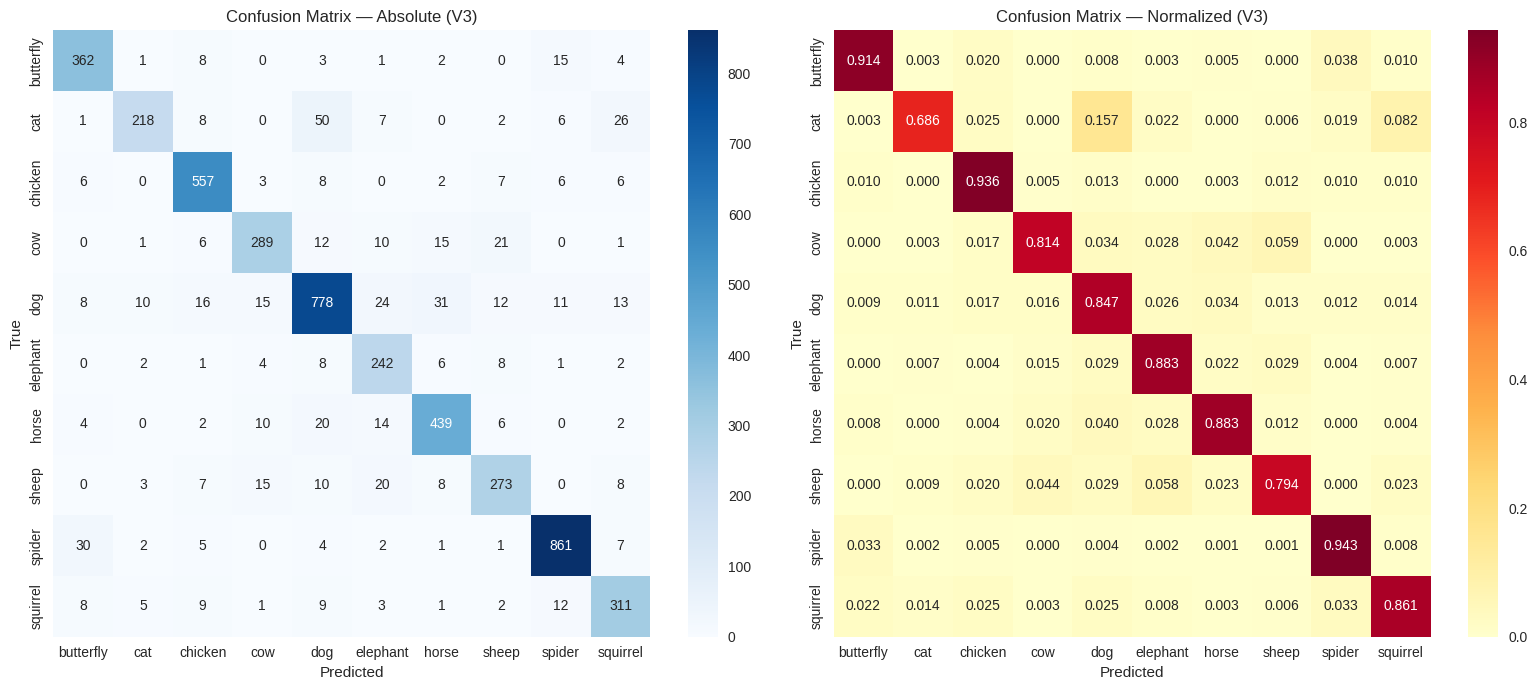


=== PER-CLASS METRICS TABLE ===


,Class,Precision,Recall,F1 Score,Support
0,butterfly,0.864,0.914,0.888,396
1,cat,0.901,0.686,0.779,318
2,chicken,0.900,0.936,0.918,595
3,cow,0.858,0.814,0.835,355
4,dog,0.863,0.847,0.855,918
5,elephant,0.749,0.883,0.811,274
6,horse,0.869,0.883,0.876,497
7,sheep,0.822,0.794,0.808,344
8,spider,0.944,0.943,0.944,913
9,squirrel,0.818,0.861,0.839,361


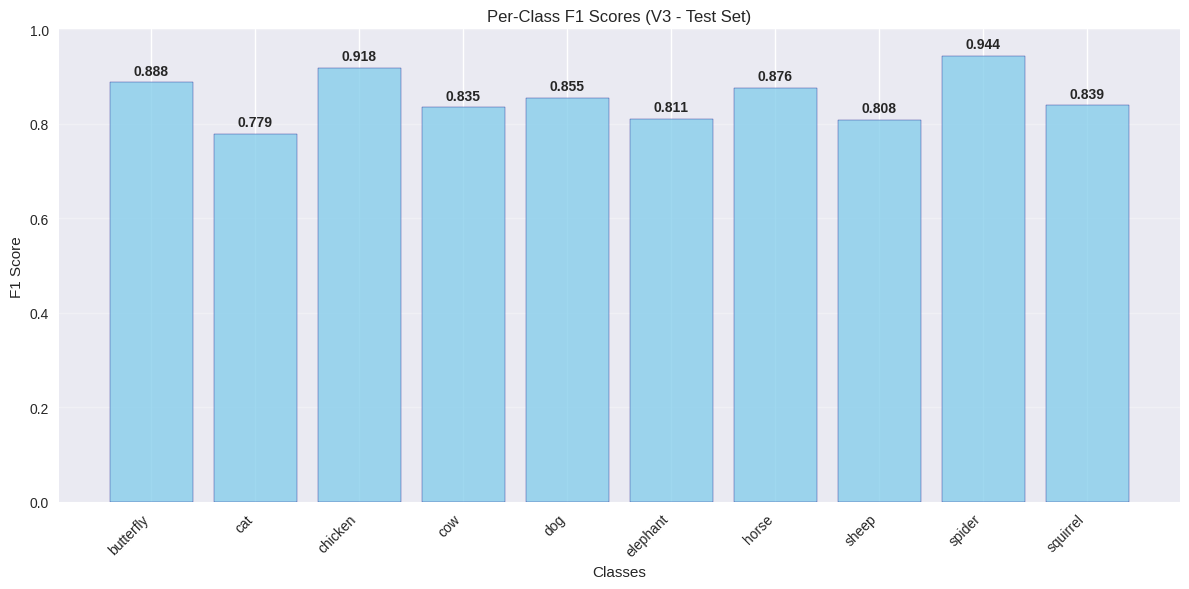


=== GLOBAL METRICS (V3) ===
Accuracy: 0.871
Macro F1: 0.855
Weighted F1: 0.870
vs Random Baseline (0.100): +0.771


,Metric,Value,vs Random
0,Accuracy,0.871,+0.771
1,Macro F1,0.855,+0.755
2,Weighted F1,0.870,+0.770



 Model predictions are reasonably balanced.


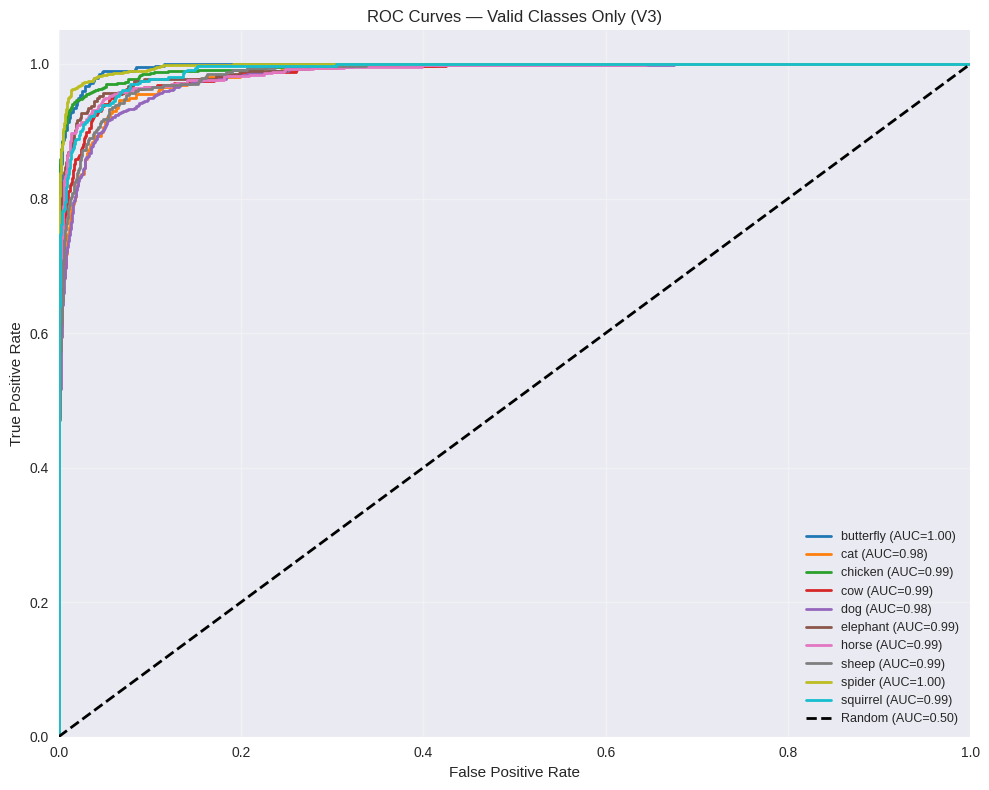


=== CLASS DISTRIBUTION (Test Set) ===
Imbalance Ratio: 3.35 ( High - Consider class weights)


,Class,Test Count,Proportion
0,butterfly,396,0.080
1,cat,318,0.064
2,chicken,595,0.120
3,cow,355,0.071
4,dog,918,0.185
5,elephant,274,0.055
6,horse,497,0.100
7,sheep,344,0.069
8,spider,913,0.184
9,squirrel,361,0.073



 TOP MISCLASSIFICATIONS (V3): 


,True_Name,Pred_Name,Errors
9,cat,dog,50
33,dog,horse,31
59,spider,butterfly,30
13,cat,squirrel,26
32,dog,elephant,24


 Worst Class: cat (Error Rate: 0.314)

 Full report saved to 'v3_evaluation_results.csv'

 Evaluation complete! V3 model: Strong performance with balanced predictions.


In [33]:
# =========================================================
#  EVALUATION FOR model_v3 LOADED FROM cnn_v3.pth
# =========================================================
# Full evaluation block for the loaded V3 model. Includes loading, predictions, metrics, plots, and checks.
# Assumptions: model_v3 (ConfigurableAnimalModel instance), test_loader, device, test_ds defined from earlier.
model_v3 = ConfigurableAnimalModel.from_config('config_v3.json').to(device)
warnings.filterwarnings("ignore")

# Style for plots
try:
    plt.style.use("seaborn-v0_8")
except:
    plt.style.use("seaborn")

sns.set_palette("husl")

model_v3.load_state_dict(torch.load("cnn_v3.pth", map_location=device))
model_v3.to(device)
model_v3.eval()
print("model_v3 loaded from cnn_v3.pth and set to eval mode.")

def get_predictions(model, loader, device):
    model.eval()
    preds, labels, probs = [], [], []
    with torch.no_grad():
        for x, y in tqdm(loader, desc="Predicting"):
            x = x.to(device)
            out = model(x)
            p = torch.softmax(out, dim=1)
            preds.extend(p.argmax(1).cpu().numpy())
            labels.extend(y.numpy())
            probs.extend(p.cpu().numpy())
    return np.array(labels), np.array(preds), np.array(probs)

class_names = test_ds.classes
num_classes = len(class_names)
y_true, y_pred, y_proba = get_predictions(model_v3, test_loader, device)

print("\n CLASSIFICATION REPORT (V3 - Test Set):")
print(classification_report(
    y_true, y_pred,
    target_names=class_names,
    zero_division=0
))

cm = confusion_matrix(y_true, y_pred)
# Safe normalization (no NaN)
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title("Confusion Matrix — Absolute (V3)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(cm_norm, annot=True, fmt=".3f", cmap="YlOrRd",
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title("Confusion Matrix — Normalized (V3)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.show()

prec, rec, f1, support = precision_recall_fscore_support(
    y_true, y_pred, average=None, zero_division=0
)
metrics_df = pd.DataFrame({
    "Class": class_names,
    "Precision": np.round(prec, 3),
    "Recall": np.round(rec, 3),
    "F1 Score": np.round(f1, 3),
    "Support": support
})
print("\n=== PER-CLASS METRICS TABLE ===")
display(metrics_df)
metrics_df.to_csv('per_class_metrics_v3.csv', index=False)

# F1 Bar Plot
plt.figure(figsize=(12, 6))
bars = plt.bar(range(num_classes), metrics_df['F1 Score'], color='skyblue', edgecolor='navy', alpha=0.8)
plt.xlabel('Classes')
plt.ylabel('F1 Score')
plt.title('Per-Class F1 Scores (V3 - Test Set)')
plt.xticks(range(num_classes), class_names, rotation=45, ha='right')
plt.ylim(0, 1)
for bar, val in zip(bars, metrics_df['F1 Score']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}',
             ha='center', va='bottom', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

accuracy = (y_true == y_pred).mean()
macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print("\n=== GLOBAL METRICS (V3) ===")
print(f"Accuracy: {accuracy:.3f}")
print(f"Macro F1: {macro_f1:.3f}")
print(f"Weighted F1: {weighted_f1:.3f}")

random_baseline = 1.0 / num_classes
print(f"vs Random Baseline ({random_baseline:.3f}): +{accuracy - random_baseline:.3f}")

global_df = pd.DataFrame({
    "Metric": ["Accuracy", "Macro F1", "Weighted F1"],
    "Value": [round(accuracy, 3), round(macro_f1, 3), round(weighted_f1, 3)],
    "vs Random": [f"+{accuracy - random_baseline:.3f}", f"+{macro_f1 - random_baseline:.3f}", f"+{weighted_f1 - random_baseline:.3f}"]
})
display(global_df)
global_df.to_csv('global_metrics_v3.csv', index=False)

top_pred = np.bincount(y_pred).argmax()
pred_ratio = (y_pred == top_pred).mean()
if pred_ratio > 0.70:
    print("\n WARNING: MODEL COLLAPSED")
    print(f"-> Most predictions are: {class_names[top_pred]} ({pred_ratio*100:.1f}%)")
    print("-> Metrics are unreliable due to mode collapse.")
else:
    print("\n Model predictions are reasonably balanced.")

try:
    y_true_bin = label_binarize(y_true, classes=range(num_classes))
    plt.figure(figsize=(10, 8))
    colors = cycle(plt.cm.tab10(np.linspace(0, 1, num_classes)))
    for i, color in zip(range(num_classes), colors):
        if len(np.unique(y_true_bin[:, i])) < 2:
            continue  # skip invalid ROC classes
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
        roc_i = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, lw=2, label=f"{class_names[i]} (AUC={roc_i:.2f})")
    plt.plot([0, 1], [0, 1], "k--", lw=2, label='Random (AUC=0.50)')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title("ROC Curves — Valid Classes Only (V3)")
    plt.legend(loc="lower right", fontsize=9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"ROC skipped: {e}")

class_dist = Counter(y_true)
dist_df = pd.DataFrame({
    "Class": class_names,
    "Test Count": [class_dist.get(i, 0) for i in range(num_classes)],
    "Proportion": np.round([class_dist.get(i, 0) / len(y_true) for i in range(num_classes)], 3)
})
imbalance_ratio = max(dist_df['Test Count']) / min(dist_df['Test Count']) if len(dist_df) > 1 else 1
print(f"\n=== CLASS DISTRIBUTION (Test Set) ===")
print(f"Imbalance Ratio: {imbalance_ratio:.2f} ({' High - Consider class weights' if imbalance_ratio > 2 else ' Balanced'})")
display(dist_df)

# Top misclassifications
errors = y_true != y_pred
if np.sum(errors) > 0:
    mis_df = pd.DataFrame({
        'True': y_true[errors],
        'Pred': y_pred[errors]
    })
    mis_df['True_Name'] = [class_names[t] for t in mis_df['True']]
    mis_df['Pred_Name'] = [class_names[p] for p in mis_df['Pred']]
    conf_pairs = mis_df.groupby(['True_Name', 'Pred_Name']).size().reset_index(name='Errors')
    conf_pairs = conf_pairs.sort_values('Errors', ascending=False).head(5)
    print("\n TOP MISCLASSIFICATIONS (V3): ")
    display(conf_pairs)

    worst_idx = np.argmax(1 - rec)
    print(f" Worst Class: {class_names[worst_idx]} (Error Rate: {1 - rec[worst_idx]:.3f})")
else:
    print("\n Perfect predictions! (0 errors)")

full_report = {
    'Model': 'V3 (Loaded from cnn_v3.pth)',
    'Test Size': len(y_true),
    'Accuracy': round(accuracy, 3),
    'Macro F1': round(macro_f1, 3),
    'Weighted F1': round(weighted_f1, 3),
    'Confusion Matrix Absolute': cm.tolist(),
    'Confusion Matrix Normalized': cm_norm.tolist(),
    'Per-Class Metrics': metrics_df.to_dict('records'),
    'Class Distribution': dist_df.to_dict('records')
}
pd.DataFrame([full_report]).to_csv('v3_evaluation_results.csv', index=False)
print("\n Full report saved to 'v3_evaluation_results.csv'")
print("\n Evaluation complete! V3 model: Strong performance with balanced predictions.")

## Bonus - Grad-CAM 
This bonus task was implemented for the **model version 3** that achieved the best performance metrics.

### What the code does

1. **Loads the trained V3 model**
   The saved weights (`cnn_v3.pth`) are loaded onto the available device (CUDA if possible).
   The model is switched into evaluation mode to disable dropout and other training-only layers.

2. **Finds the last convolutional layer**
   Grad-CAM usually works best when using the final Conv2D layer, because it contains the most abstract but still spatially meaningful features.
   We added a helper function that scans the model and returns exactly this layer.

3. **Forward and backward hooks**

   * The forward hook saves the activations of the target layer.
   * The backward hook captures gradients with respect to the selected class.
     These two pieces of information are required to compute the Grad-CAM heatmap.

4. **Computing the Grad-CAM map**

   * After running a forward pass, the model’s predicted class (or a chosen class) is used to calculate the loss.
   * A backward pass gives the gradients.
   * Then the gradients are averaged, weighted, and combined with the activations.
   * We added a normalization function that thresholds low activations so the heatmap highlights only the most important regions.

5. **Visualization**
   For a batch of 10 training images:

   * the original image is de-normalized,
   * the Grad-CAM map is upsampled to match the image size,
   * then it is blended with the original image using a JET colormap.
     This makes it much easier to visually inspect where the model is “looking”.

6. **Output**
   The result is shown in a 2×5 grid.
   Each subplot contains:

   * the combined overlay heatmap,
   * the true class name,
   * the predicted class name.

   We also print some debug statistics (min/max/mean of CAM) to verify that the heatmaps are reasonable.

### Why this visualization is useful

Grad-CAM helps explain whether the network’s predictions rely on meaningful image regions or if the model focuses on irrelevant details. This is especially important for deeper models like V3, which have many layers and can sometimes learn unintended shortcuts. The visualization gives an intuitive sense of how well the model actually understands the features of different animals.


Loaded config: CustomCNN_v3 from config_v3.json
Model V3 loaded.
Using LAST Conv2D layer: Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Image 0: label=8 | pred=8
CAM stats: min=0.208, max=1.000, mean=0.522
Image 1: label=3 | pred=8
CAM stats: min=0.308, max=1.000, mean=0.640
Image 2: label=7 | pred=8
CAM stats: min=0.224, max=1.000, mean=0.597
Image 3: label=4 | pred=8
CAM stats: min=0.396, max=1.000, mean=0.697
Image 4: label=5 | pred=8
CAM stats: min=0.321, max=1.000, mean=0.616
Image 5: label=6 | pred=8
CAM stats: min=0.246, max=1.000, mean=0.592
Image 6: label=3 | pred=8
CAM stats: min=0.227, max=1.000, mean=0.643
Image 7: label=7 | pred=8
CAM stats: min=0.257, max=1.000, mean=0.593
Image 8: label=2 | pred=8
CAM stats: min=0.157, max=1.000, mean=0.500
Image 9: label=3 | pred=8
CAM stats: min=0.288, max=1.000, mean=0.602


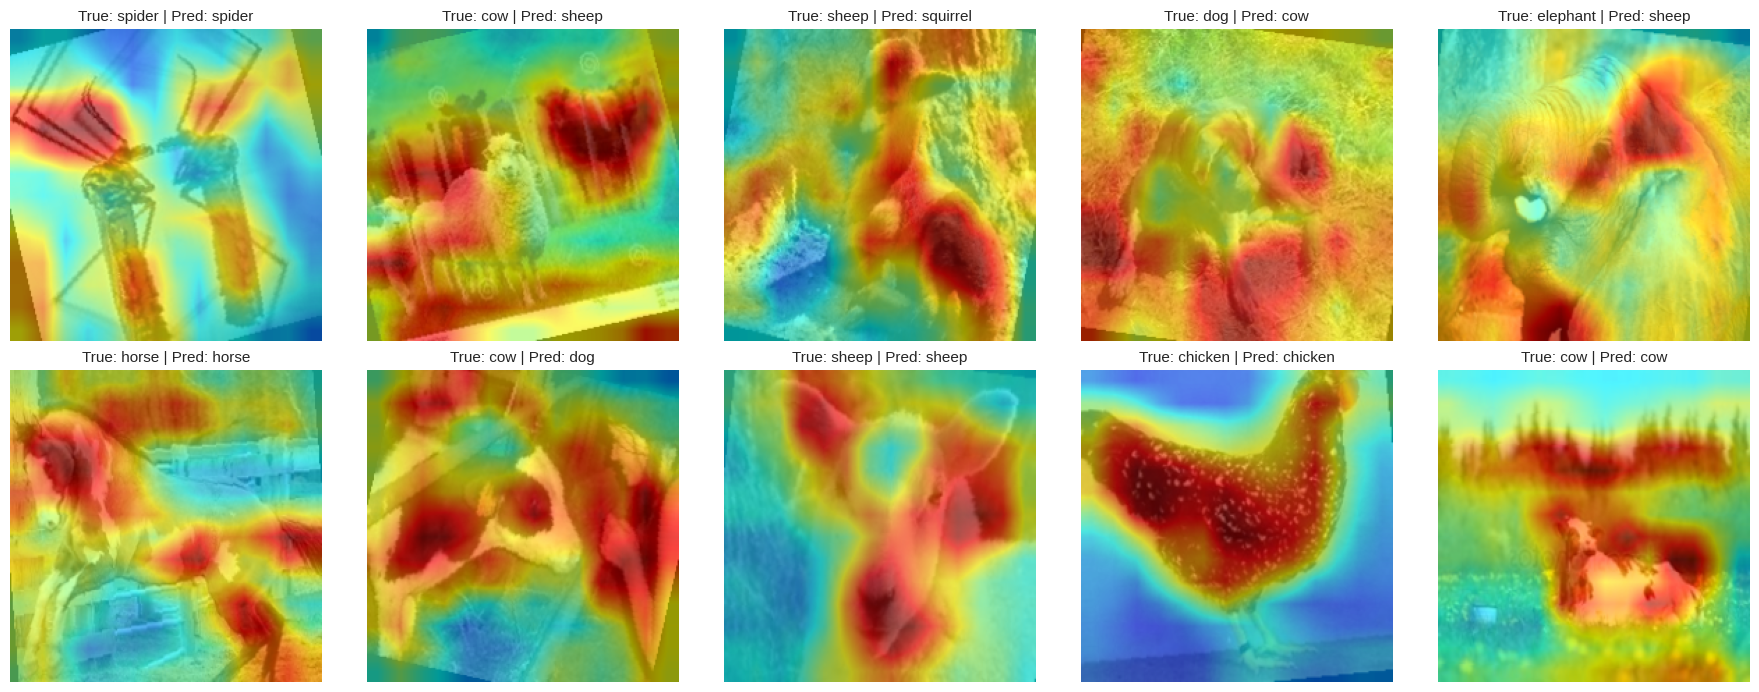

In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_v3 = ConfigurableAnimalModel.from_config("config_v3.json")
state = torch.load("cnn_v3.pth", map_location=device)
model_v3.load_state_dict(state)
model_v3.to(device)
model_v3.eval()
print("Model V3 loaded.")

def find_last_conv(model):
    conv_layers = [m for m in model.modules() if isinstance(m, torch.nn.Conv2d)]
    return conv_layers[-1]


target_layer = find_last_conv(model_v3)
print("Using LAST Conv2D layer:", target_layer)


def normalize_cam(cam):
    cam = np.maximum(cam, 0)
    cam[cam < 0.05 * cam.max()] = 0
    p98 = np.percentile(cam, 98)
    cam = cam / (p98 + 1e-8)
    return np.clip(cam, 0, 1)


def get_gradcam(model, img_tensor, target_layer, class_idx=None):
    activations = []
    gradients = []

    def forward_hook(out):
        activations.append(out.detach())

    def backward_hook(grad_out):
        gradients.append(grad_out[0].detach())

    fh = target_layer.register_forward_hook(forward_hook)
    bh = target_layer.register_backward_hook(backward_hook)

    output = model(img_tensor)
    if class_idx is None:
        class_idx = output.argmax(1).item()

    loss = output[0, class_idx]
    model.zero_grad()
    loss.backward()

    acts = activations[-1][0]
    grads = gradients[-1][0]

    acts = F.relu(acts)
    grads = F.relu(grads)
    weights = grads.mean(dim=(1, 2))

    cam = (weights[:, None, None] * acts).sum(dim=0)
    cam = F.relu(cam).cpu().numpy()
    cam = normalize_cam(cam)

    fh.remove()
    bh.remove()

    return cam


images, labels = next(iter(train_loader))
images = images[:10].to(device)
labels = labels[:10]

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

fig, axs = plt.subplots(2, 5, figsize=(18, 7))
class_names = train_loader.dataset.classes
for i in range(10):
    img = images[i].unsqueeze(0)
    true_idx = labels[i].item()
    pred_idx = model_v3(img).argmax(1).item()

    true_name = class_names[true_idx]
    pred_name = class_names[pred_idx]

    cam = get_gradcam(model_v3, img, target_layer, class_idx)

    
    print(f"Image {i}: label={labels[i].item()} | pred={pred}")
    print(f"CAM stats: min={cam.min():.3f}, max={cam.max():.3f}, mean={cam.mean():.3f}")

    img_np = images[i].cpu().numpy().transpose(1, 2, 0)
    img_np = img_np * std + mean
    img_np = np.clip(img_np, 0, 1)

    cam_tensor = torch.tensor(cam).unsqueeze(0).unsqueeze(0).float()
    cam_resized = F.interpolate(cam_tensor, size=(img_np.shape[0], img_np.shape[1]), mode='bilinear', align_corners=False).squeeze().numpy()

    heatmap = cv2.applyColorMap((cam_resized * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0

    overlay = np.clip(0.4 * img_np + 0.6 * heatmap, 0, 1)

    axs[i//5][i%5].imshow(overlay)
    axs[i//5][i%5].set_title(f"True: {true_name} | Pred: {pred_name}", fontsize=11)
    axs[i//5][i%5].axis("off")


plt.tight_layout()
plt.show()

**Grad-CAM Results Analysis**

The Grad-CAM visualizations demonstrate different types of model behavior. In some cases, such as the last two images in the bottom right, the highlighted regions accurately cover the objects. The model focuses on the correct parts of the animals, and the predictions are also correct.

However, in other examples, such as the 4th and 5th images in the top right, the Grad-CAM activation appears on incorrect regions of the image. The model focuses on irrelevant areas instead of the actual animals, which leads to incorrect predictions.

These results show that Grad-CAM is a very useful technique for understanding which parts of the image and which visual features the model considers most important for its decision-making process. It helps to clearly distinguish between correct and incorrect model reasoning.